# Iteración 2: Modelo XGBoost para Predicción de Gastos (Con Lags)

Este cuaderno implementa **XGBoost Regressor**, un algoritmo basado en árboles de decisión extremadamente popular y poderoso. A diferencia de Prophet, XGBoost no entiende el "tiempo" por sí solo, por lo que nosotros debemos extraer la estacionalidad del verano y relacionarlo manualmentente creando nuevas variables (*Feature Engineering*).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

### 1. Carga y Limpieza de Datos

In [3]:
# Cargar datos
file_path = '../data/raw/db_orig.csv'
df = pd.read_csv(file_path)

# Limpieza
df['Amount'] = df['Amount'].str.replace('€', '', regex=False)
df['Amount'] = df['Amount'].str.replace('.', '', regex=False)
df['Amount'] = df['Amount'].str.replace(',', '.', regex=False)
df['Amount'] = pd.to_numeric(df['Amount'])

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

display(df.head())

,Description,Date,Amount,Area,Type
0,Entretenimiento,2026-02-28,10.00,Leisure,Expenses
1,Nómina mensual,2026-02-27,629.58,Salary,Income
2,Gasto vacaciones,2026-02-25,51.00,"Leisure, Vacations",Expenses
3,Pequeño ocio,2026-02-22,2.80,Leisure,Expenses
4,Compra alimentación,2026-02-21,24.80,Food,Expenses


### 2. Agrupación e Ingeniería de Características (Feature Engineering)
Para que XGBoost entienda que los ingresos pasados afectan a los gastos futuros, creamos las llamadas **"Lag Features"** (Valores atrasados).

In [4]:
# Agrupar por mes
df['Month_End'] = df['Date'].dt.to_period('M').dt.to_timestamp('M')
monthly = df.groupby(['Month_End', 'Type'])['Amount'].sum().unstack(fill_value=0).reset_index()

if 'Expenses' not in monthly.columns: monthly['Expenses'] = 0
if 'Income' not in monthly.columns: monthly['Income'] = 0

ml_df = monthly.copy()

# Extraer características temporales (Para que entienda qué mes del año es el "verano")
ml_df['Month'] = ml_df['Month_End'].dt.month
ml_df['Is_Summer'] = ml_df['Month'].isin([6, 7, 8, 9]).astype(int)  # Jun, Jul, Ago, Sep

# Lags: ¿Cuánto ingresó el mes pasado? ¿Y hace 2 meses?
ml_df['Income_Lag_1'] = ml_df['Income'].shift(1)
ml_df['Income_Lag_2'] = ml_df['Income'].shift(2)

# Lags de Gastos: Inercia de gastos (Costumbre)
ml_df['Expenses_Lag_1'] = ml_df['Expenses'].shift(1)

# Eliminar NaNs generados por los shifts en los primeros meses
ml_df = ml_df.dropna()

display(ml_df.head())

Type,Month_End,Expenses,Income,Month,Is_Summer,Income_Lag_1,Income_Lag_2,Expenses_Lag_1
2,2021-11-30,258.91,270.07,11,0,115.00,1250.62,328.70
3,2021-12-31,201.43,487.50,12,0,270.07,115.00,258.91
4,2022-01-31,79.02,203.99,1,0,487.50,270.07,201.43
5,2022-02-28,214.39,285.34,2,0,203.99,487.50,79.02
6,2022-03-31,439.85,659.10,3,0,285.34,203.99,214.39


### 3. Entrenamiento (Train/Test Split)

In [5]:
# Definir variable objetivo (Target) y Features
FEATURES = ['Month', 'Is_Summer', 'Income', 'Income_Lag_1', 'Income_Lag_2', 'Expenses_Lag_1']
TARGET = 'Expenses'

X = ml_df[FEATURES]
y = ml_df[TARGET]

# Como es serie temporal, no hacemos un split aleatorio. 
# Usamos los últimos 6 meses (20%) como validación.
split_idx = int(len(ml_df) * 0.8)

X_train = X[:split_idx]
y_train = y[:split_idx]
X_test = X[split_idx:]
y_test = y[split_idx:]

# Inicializar modelo XGBoost 
reg = xgb.XGBRegressor(n_estimators=1000, early_stopping_rounds=50, learning_rate=0.01)

# Entrenar
reg.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=100)

[0]	validation_0-rmse:210.36867	validation_1-rmse:362.68599
[50]	validation_0-rmse:157.75699	validation_1-rmse:363.36333


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

### 4. Evaluación y Predicción

Validación - Error Absoluto Medio (MAE): 280.29€
Validación - Raíz del Error Cuadrático (RMSE): 362.69€


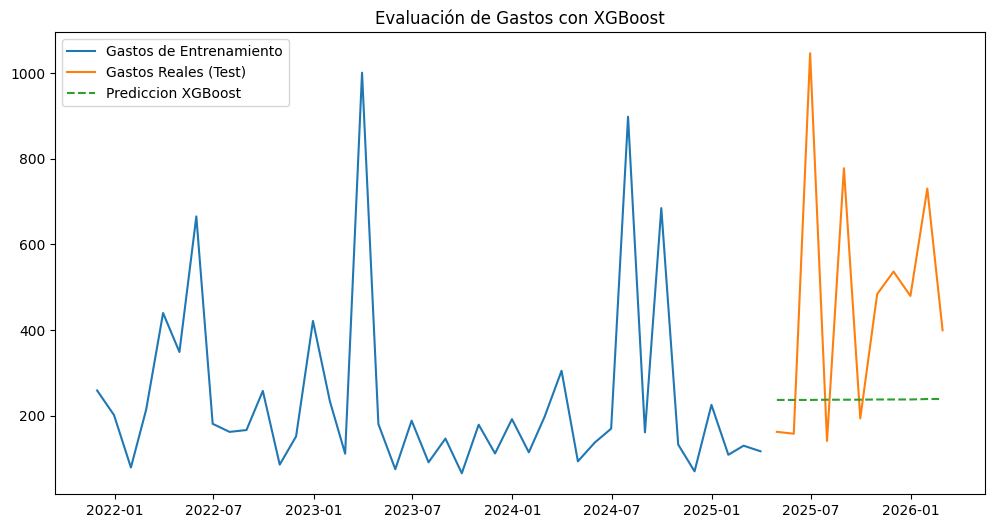

In [6]:
predictions = reg.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"Validación - Error Absoluto Medio (MAE): {mae:.2f}€")
print(f"Validación - Raíz del Error Cuadrático (RMSE): {rmse:.2f}€")

# Unir resultados para gráficar
test_df = ml_df[split_idx:].copy()
test_df['Prediction'] = predictions

plt.figure(figsize=(12, 6))
plt.plot(ml_df['Month_End'][:split_idx], y_train, label='Gastos de Entrenamiento')
plt.plot(test_df['Month_End'], y_test, label='Gastos Reales (Test)')
plt.plot(test_df['Month_End'], test_df['Prediction'], label='Prediccion XGBoost', linestyle='--')

plt.legend()
plt.title('Evaluación de Gastos con XGBoost')
plt.show()

### 5. Importancia de las Variables (Feature Importance)
¿Qué pesa más a la hora de predecir? ¿El mes en el que estamos, o lo que se ingresó hace 2 meses?

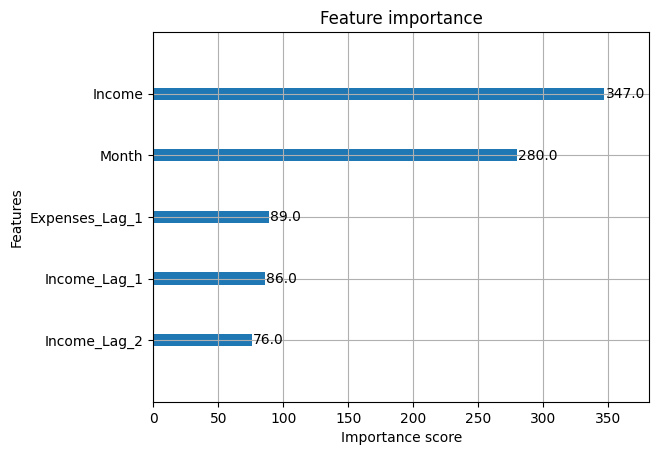

In [7]:
# Ver qué variables influyen más en el modelo
xgb.plot_importance(reg, importance_type='weight')
plt.show()